## k-Nearest Neighbors (Classification)

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [2]:
df=pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [15]:
df.drop(['ID','No_Pation'],axis=1,inplace=True)

KeyError: "['ID', 'No_Pation'] not found in axis"

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  1009 non-null   object 
 1   AGE     1008 non-null   float64
 2   Urea    1008 non-null   float64
 3   Cr      1007 non-null   float64
 4   HbA1c   1006 non-null   float64
 5   Chol    1007 non-null   float64
 6   TG      1007 non-null   float64
 7   HDL     1008 non-null   float64
 8   LDL     1007 non-null   float64
 9   VLDL    1008 non-null   float64
 10  BMI     1009 non-null   float64
 11  CLASS   1009 non-null   object 
dtypes: float64(10), object(2)
memory usage: 94.7+ KB


In [16]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [17]:
x=df.drop('CLASS',axis=1)
y=df['CLASS']

In [18]:
x=pd.get_dummies(x,drop_first=True)

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8712871287128713


In [23]:
#PB 268

In [24]:
df=pd.read_csv("cancer.csv")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [26]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [27]:
df.head(2)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [28]:
x=df.drop('diagnosis',axis=1)
y=df['diagnosis']

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9473684210526315


In [40]:
acc=[]
for i in range(3,24):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    acc.append(accuracy_score(y_test,y_pred))
print(max(acc))
print(acc.index(max(acc))+3)

0.9473684210526315
7


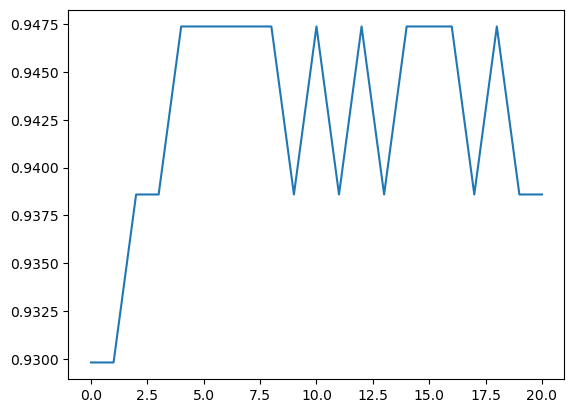

In [41]:
plt.plot(acc)
plt.show()

In [42]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9473684210526315


In [43]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print(cm)

[[65  1]
 [ 5 43]]


In [54]:
from sklearn.metrics import confusion_matrix
y_act=['Y','Y','Y','N','N','N','Y','Y','N','N','Y','Y','Y','N','N']
y_pred=['Y','Y','N','N','N','N','Y','Y','Y','Y','Y','N','Y','Y','N']
cm= confusion_matrix(y, x)

In [55]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [56]:
print((TN+TP)/(TN+TP+FN+FP))

0.6666666666666666


In [57]:
print(TP/(TP+FP))

0.6666666666666666


In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_act, y_pred))

              precision    recall  f1-score   support

           N       0.67      0.57      0.62         7
           Y       0.67      0.75      0.71         8

    accuracy                           0.67        15
   macro avg       0.67      0.66      0.66        15
weighted avg       0.67      0.67      0.66        15



In [60]:
from sklearn.datasets import load_iris
iris = load_iris()
x=iris.data
y=iris.target

In [63]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [65]:
df=pd.read_csv("Churn.csv")
df.head(2)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


## Decision Tree (Classification)

In [21]:
df=pd.read_csv('decision.csv')
df.head(2)

,CGPA,Communication,Aptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1


In [22]:
x=df.drop('Job Offered',axis=1)
y=df['Job Offered']

In [23]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',max_depth=2)
dt.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


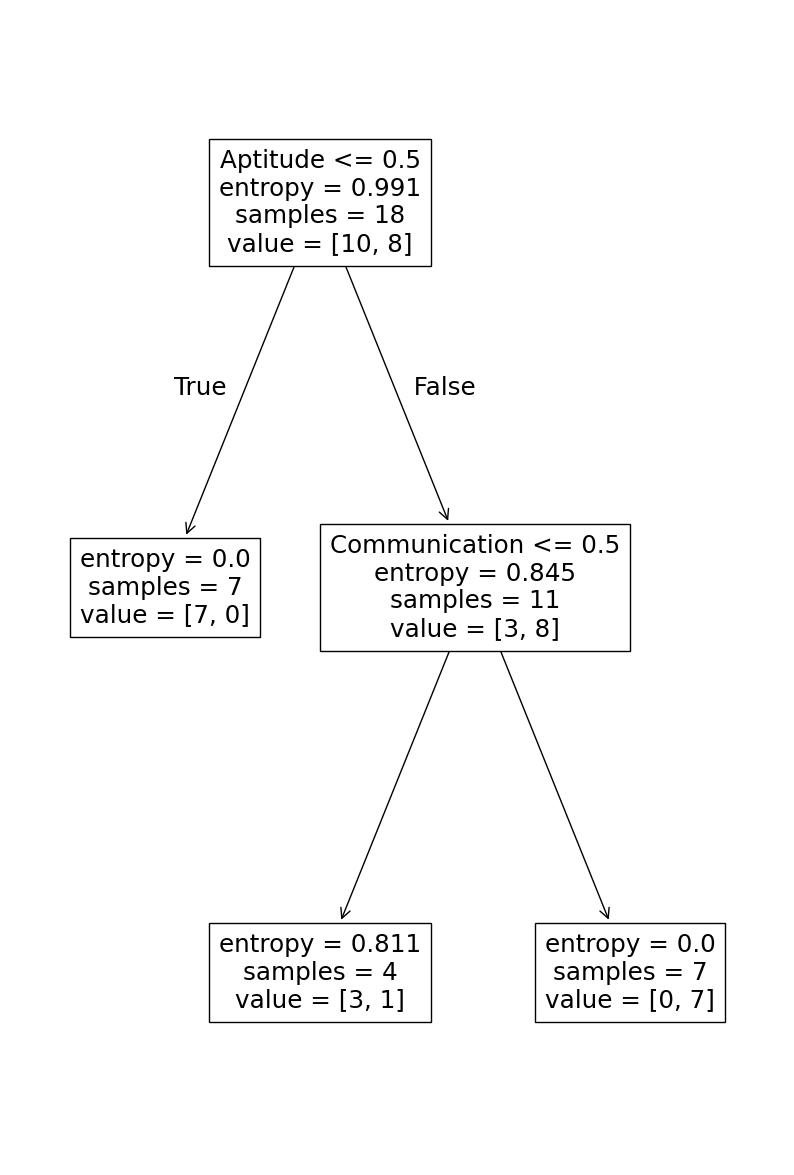

In [24]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,15))
plot_tree(dt, feature_names=x.columns)
plt.show()

In [25]:
df=pd.read_csv("Churn.csv")
df.head(2)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [26]:
df.drop(['Unnamed: 0','customerID'],axis=1, inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [28]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [29]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [30]:
x= pd.get_dummies(x, drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[905 161]
 [159 184]]
              precision    recall  f1-score   support

          No       0.85      0.85      0.85      1066
         Yes       0.53      0.54      0.53       343

    accuracy                           0.77      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.77      0.77      0.77      1409



In [33]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train, y_train)
y_pred=dt.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[879 187]
 [172 171]]
              precision    recall  f1-score   support

          No       0.84      0.82      0.83      1066
         Yes       0.48      0.50      0.49       343

    accuracy                           0.75      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.75      0.75      0.75      1409



In [34]:
from sklearn.metrics import recall_score, precision_score, f1_score
print(recall_score(y_test,y_pred,pos_label='Yes'))
print(precision_score(y_test,y_pred,pos_label='Yes'))
print(f1_score(y_test,y_pred,pos_label='Yes'))

0.49854227405247814
0.4776536312849162
0.48787446504992865


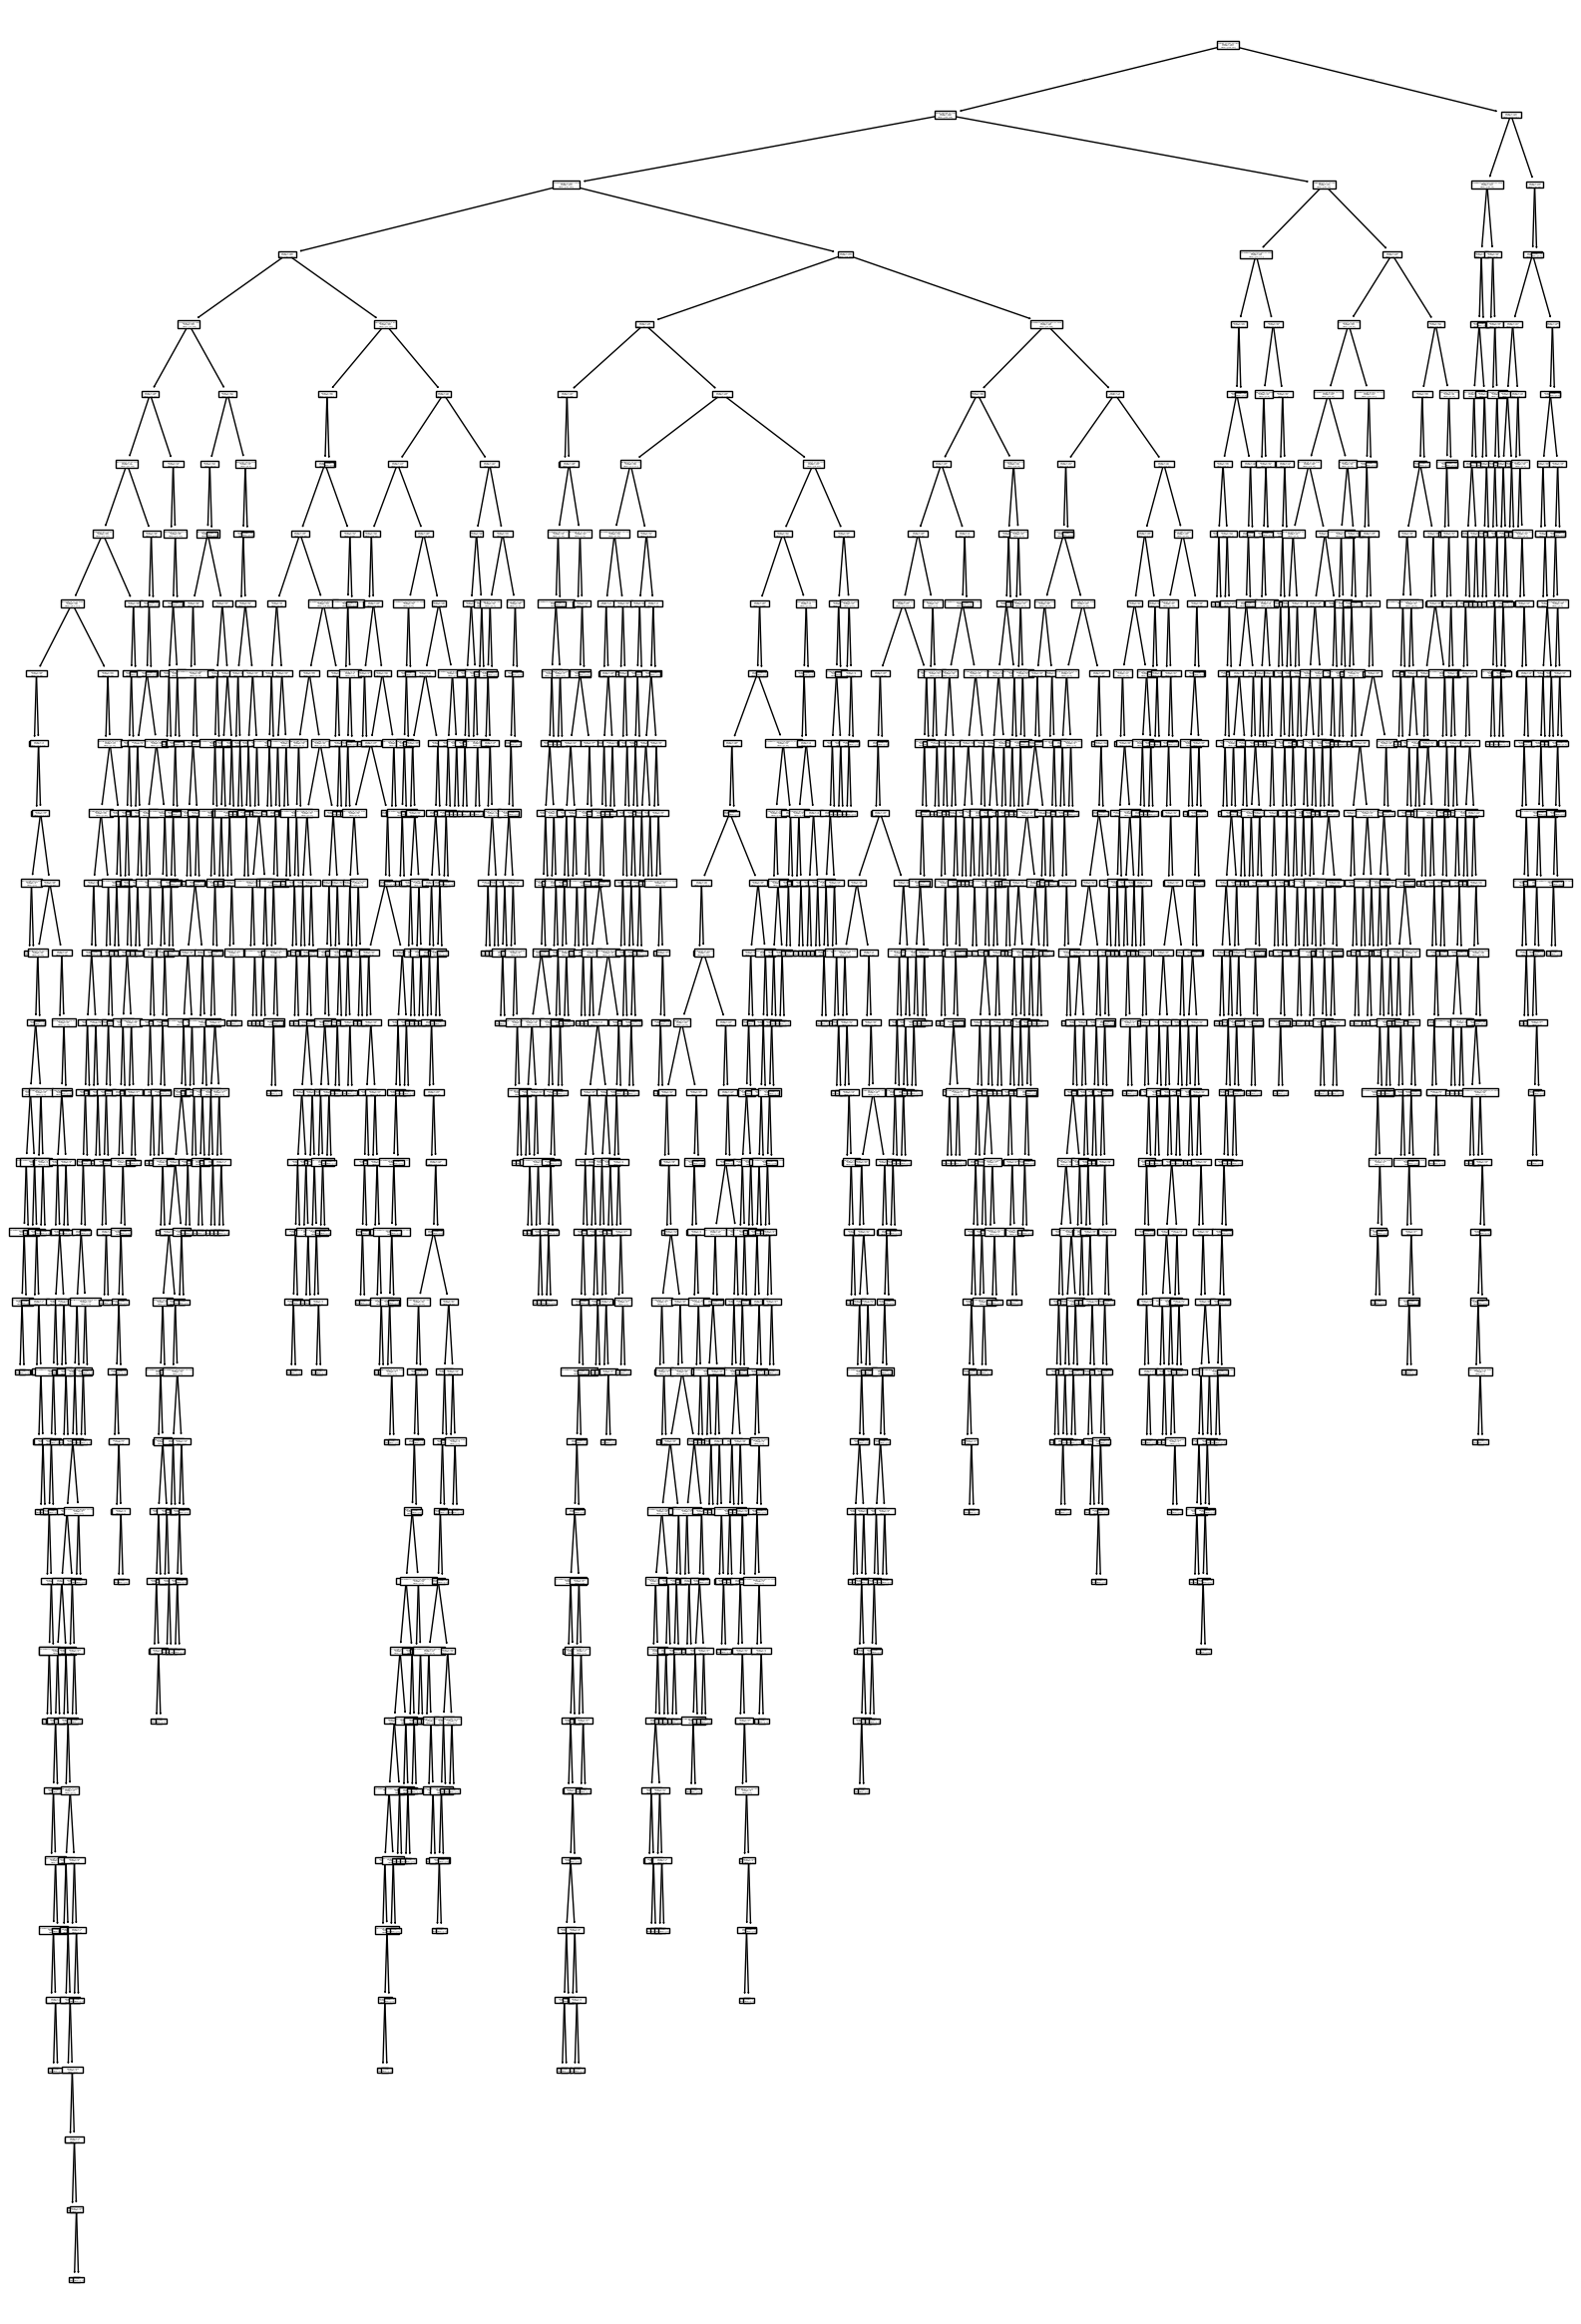

In [35]:
plt.figure(figsize=(20,30))
plot_tree(dt,feature_names=x.columns)
plt.show()

In [16]:
df=pd.read_csv('loan_approval.csv')
df.head(2)

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes


In [17]:
df.shape

(13, 10)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            13 non-null     int64  
 1   Income         12 non-null     float64
 2   CreditScore    13 non-null     int64  
 3   LoanAmount     12 non-null     float64
 4   Dependents     13 non-null     int64  
 5   Education      13 non-null     object 
 6   SelfEmployed   13 non-null     object 
 7   PropertyArea   13 non-null     object 
 8   PreviousLoans  13 non-null     int64  
 9   LoanApproved   13 non-null     object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1.1+ KB


In [19]:
df.fillna(df.median(numeric_only=True),inplace=True)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.shape

(12, 10)

In [22]:
x=df.drop('LoanApproved',axis=1)
y=df['LoanApproved']
x=pd.get_dummies(x,drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[1 0]
 [1 1]]
              precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [25]:
from sklearn.metrics import recall_score, precision_score, f1_score
r_knn=recall_score(y_test,y_pred,pos_label='Yes')
p_knn=precision_score(y_test,y_pred,pos_label='Yes')
f1_knn=f1_score(y_test,y_pred,pos_label='Yes')
from sklearn.metrics import accuracy_score
acc_knn=accuracy_score(y_test,y_pred)

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train, y_train)
y_pred=dt.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [27]:
from sklearn.metrics import recall_score, precision_score, f1_score
r_dt=recall_score(y_test,y_pred,pos_label='Yes')
p_dt=precision_score(y_test,y_pred,pos_label='Yes')
f1_dt=f1_score(y_test,y_pred,pos_label='Yes')
acc_dt=accuracy_score(y_test,y_pred)

In [28]:
df1=pd.DataFrame({'Model':['KNN','Decision Tree'],
                 'Accuracy':[acc_knn,acc_dt],
                 'Precision':[p_knn,p_dt],
                 'Recall':[r_knn,r_dt]})

In [29]:
df1

,Model,Accuracy,Precision,Recall
0,KNN,0.666667,1.0,0.5
1,Decision Tree,1.000000,1.0,1.0


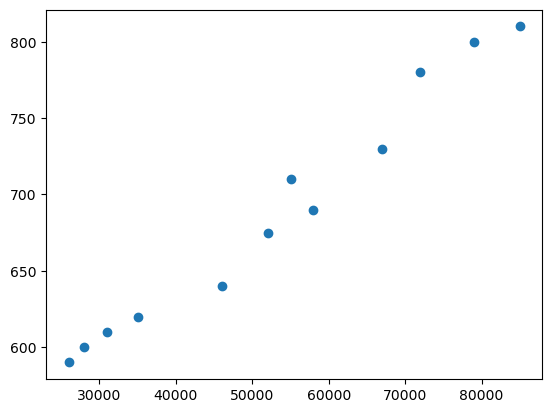

In [30]:
plt.scatter(df['Income'],df['CreditScore'])
plt.show()

<Axes: ylabel='LoanAmount'>

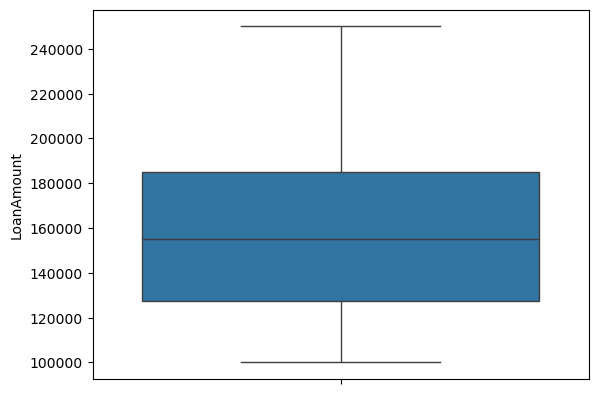

In [32]:
sns.boxplot(data=df['LoanAmount'])

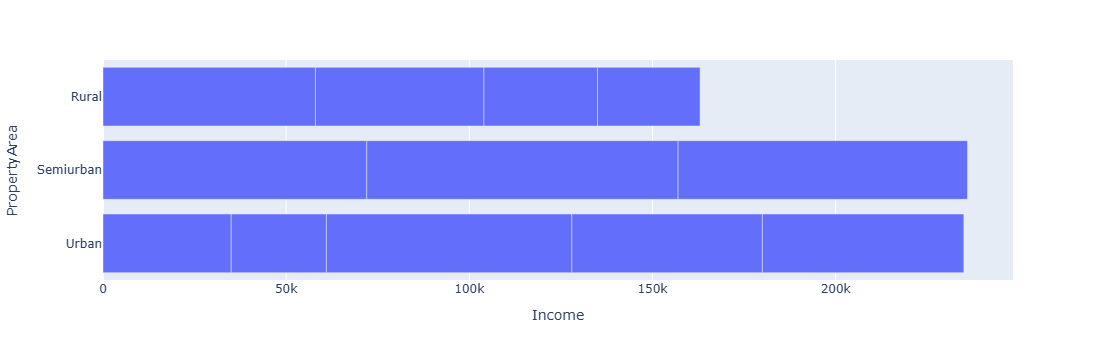

In [37]:
px.bar(df, x='Income', y='PropertyArea')

In [38]:
new = df.groupby("PropertyArea",as_index=False)["Income"].mean()

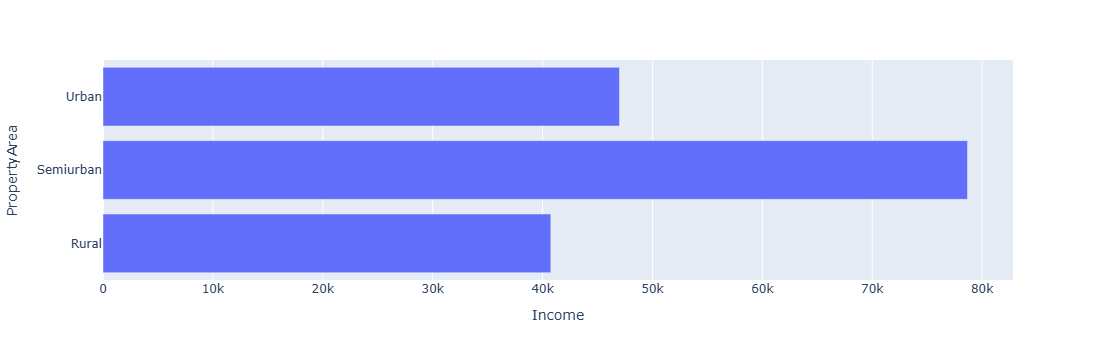

In [40]:
px.bar(new, x='Income', y='PropertyArea')

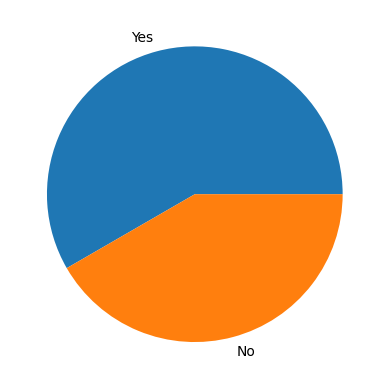

In [44]:
plt.pie(df['LoanApproved'].value_counts(),labels=['Yes','No'])
plt.show()

In [45]:
df=pd.read_csv('loan_approval.csv')
df.head(2)

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes


In [ ]:
Age - 18
Income - 25000
CreditScore - 750
LoanAmount - 100000
Dependents - 0
Education - Not Graduate
SelfEmployed - No
PropertyArea - Urban
PreviousLoans - 0

In [46]:
x_test.columns

Index(['Age', 'Income', 'CreditScore', 'LoanAmount', 'Dependents',
       'PreviousLoans', 'Education_Not Graduate', 'SelfEmployed_Yes',
       'PropertyArea_Semiurban', 'PropertyArea_Urban'],
      dtype='object')

In [49]:
x=np.array([[18,40000,750,100000,0,0,True,False,False,True]])
print(dt.predict(x))
print(knn.predict(x))

['Yes']
['No']


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but KNeighborsClassifier was fitted with feature names



## Random Forest Classifier

In [50]:
df=pd.read_csv('Churn.csv')
df.head(2)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [51]:
df.drop(['Unnamed: 0','customerID'],axis=1, inplace=True)

In [61]:
df.dropna(inplace=True)

In [62]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [63]:
x = pd.get_dummies(x, drop_first=True)

In [64]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [65]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=10,n_estimators=50,criterion='entropy',max_depth=12)
rf.fit(x_train,y_train)

,n_estimators,50
,criterion,'entropy'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred = rf.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1046
         Yes       0.66      0.58      0.62       361

    accuracy                           0.82      1407
   macro avg       0.76      0.74      0.75      1407
weighted avg       0.81      0.82      0.81      1407



## Support Vector Classifier (SVC)

In [67]:
from sklearn.svm import SVC
s = SVC(kernel='rbf',C=10,random_state=10)
s.fit(x_train,y_train)
y_pred = s.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.80      0.97      0.88      1046
         Yes       0.76      0.29      0.42       361

    accuracy                           0.80      1407
   macro avg       0.78      0.63      0.65      1407
weighted avg       0.79      0.80      0.76      1407

